# Visualization

In [1]:
import contextlib
import pandas as pd
import polars as pl
from tqdm import tqdm
import os
import random
import numpy as np

In [2]:
SEED = 123456789
os.environ["PYTHONHASHSEED"] = str(SEED)      # deterministic dict order
random.seed(SEED)                            # Python's random
np.random.seed(SEED)

In [3]:
# On simplifie en 8 grands partis d'après https://fr.wikipedia.org/wiki/Liste_des_partis_politiques_en_France_sous_la_Cinqui%C3%A8me_R%C3%A9publique
# On ne code pas tout de suite par un nombre pour pouvoir extraire des sous-graphes
corrections = {
    'non mentionné' : '',
    'indépendant' : '',
    'indépendants' : '',
    'sans étiquette' : '',
    'libre' : '',
    'libres' : '',
    'non inscrits' : '',
    'non inscrit' : '',
    'sans parti politique' : '',
    'hors des partis' : '',
    'abertzale' : '',
    'Fédération nationale des indépendants' : '',
    'Front national' : 'Extrême droite',
    'Rassemblement pour la République' : 'Droite',
    'Union gaulliste pour la démocratie' : 'Droite',
    'Mouvement des gaullistes populaires' : 'Droite',
    'Mouvement solidarité participation' : 'Droite',
    'Parti républicain' : 'Droite',
    'divers droite' : 'Droite',
    'droite' : 'Droite',
    'Centre national des indépendants et paysans' : 'Droite',
    'centre droit' : 'Centre droit', # proche udf en 1988
    'Parti ouvrier européen' : 'Centre droit', # proche udf en 1988
    'Centre des démocrates sociaux' : 'Centre droit',
    'Républicains de progrès' : 'Centre droit',
    'Parti radical' : 'Centre droit',
    'radical' : 'Centre droit',
    'Union pour la démocratie française' : 'Centre droit',
    'Parti radical-socialiste' : 'Centre droit', # pas parti radical de gauche
    'centriste' : 'Centre',
    'centre' : 'Centre',
    'Démocrates de progrès' : 'Centre',
    'centre gauche' : 'Centre gauche',
    'Parti social-démocrate' : 'Centre gauche',
    'Parti démocrate français' : 'Centre gauche',
    'Mouvement des radicaux de gauche' : 'Centre gauche',
    'gauche' : 'Gauche',
    'socialiste' : 'Gauche',
    'socialistes' : 'Gauche',
    'Humaniste' : 'Gauche',
    'Parti humaniste' : 'Gauche',
    'Parti socialiste' : 'Gauche',
    'Parti socialiste unifié' : 'Gauche',
    'Mouvement rouge et vert' : 'Gauche',
    'Comités d\'initiative pour une nouvelle politique à gauche' : 'Gauche',
    'Parti communiste français' : 'Gauche',
    'Parti communiste réunionnais' : 'Gauche',
    'Parti communiste guadeloupéen' : 'Gauche',
    'Verts alternatifs' : 'Verts',
    'Parti vert' : 'Verts',
    'Jura écologie' : 'Verts',
    'vert indépendant' : 'Verts',
    'Mouvement écologique' : 'Verts',
    'Anjou écologie autogestion' : 'Verts',
    'Comités Juquin' : 'Extrême gauche' # LCR
}

In [4]:
# On introduit un index de position
index_position = {
    'Extrême droite' : 1.,    'Droite' : 0.8,
    'Centre droit' : 0.6,    'Centre gauche' : 0.4,
    'Gauche' : 0.2, 'Extrême gauche':0., 'Centre':0.5, 'Verts':0.4, '':None
}

In [5]:
df = pl.read_parquet("df_gliner_full.parquet").with_columns(
    pl.col("titulaire-soutien")
        .str.split(";")
        .map_elements(lambda l: l.replace_strict(corrections,default="").unique(), pl.List(pl.String))
        .alias("titulaire-soutien-list")
).with_columns(
    pl.col("titulaire-soutien-list")
        .map_elements(lambda l: l.replace_strict(index_position,default=float("nan")).mean(), pl.Float64)
        .alias("titulaire-soutien-position")
).filter(pl.col("titulaire-soutien-position").is_not_null())
df.select(pl.col("titulaire-soutien-list"),pl.col("titulaire-soutien-position"))

titulaire-soutien-list,titulaire-soutien-position
list[str],f64
"[""Extrême droite""]",1.0
"[""Extrême gauche""]",0.0
"[""Centre droit"", ""Droite""]",0.7
"[""Gauche""]",0.2
"[""Gauche""]",0.2
…,…
"["""", ""Droite"", ""Centre droit""]",0.7
"[""Gauche""]",0.2
"[""Gauche""]",0.2


# Document embeddings with Word2Vec

In [6]:
# inspired from https://www.geeksforgeeks.org/nlp/doc2vec-in-nlp/

In [7]:
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import spacy
nlp = spacy.load('fr_core_news_sm')

In [8]:
def tag_transcript(i:int,s:str):
    w = [str(token) for token in nlp.make_doc(s.lower())]
    return TaggedDocument(words=w,tags=[str(i)]) 

# preproces the documents, and create TaggedDocuments
tagged_data = [tag_transcript(i,doc) for i,doc in tqdm(enumerate(df["transcript"]), desc="Tagging transcripts")]
tagged_data[0]

Tagging transcripts: 1986it [00:19, 99.95it/s] 


TaggedDocument(words=['élections', 'législatives', 'du', '5', 'juin', '1988', '-', 'département', 'de', "l'", 'ain', '-', '1re', 'circonscription', '\n', 'sciences', 'po', '/', 'fonds', 'cevipof', '\n', 'maintenant', 'la', 'force', "d'", 'avenir', "c'", 'est', 'le', 'front', 'national', '\n', 'appel', 'aux', 'français', ',', '\n', 'le', '24', 'avril', ',', '4.400.000', 'électrices', 'et', 'électeurs', "m'", 'ont', 'fait', 'confiance', ':', '-', 'pour', 'promouvoir', 'le', 'programme', 'de', 'redressement', 'national', ',', '-', 'pour', 'réduire', 'le', 'chômage', ',', "l'", 'immigration', ',', "l'", 'insécurité', ',', '-', 'pour', 'lutter', 'contre', 'le', 'socialisme', 'bureaucratique', 'et', 'fiscaliste', '.', 'je', 'leur', 'demande', 'de', 'confirmer', 'et', "d'", 'amplifier', 'leur', 'vote', 'le', '5', 'juin', 'prochain', '.', '\n', 'la', 'réélection', 'de', 'françois', 'mitterrand', 'a', 'été', 'rendue', 'possible', 'par', 'les', 'erreurs', 'et', 'les', 'faiblesses', 'du', 'rpr', 

In [9]:
# train the Doc2vec model
model = Doc2Vec(vector_size=60,
                min_count=5, epochs=50,
               seed=SEED)
model.build_vocab(tagged_data)
model.train(tagged_data,
            total_examples=model.corpus_count,
            epochs=model.epochs)

# Visualisation

In [12]:
from sklearn.manifold import TSNE

In [13]:
matrix = np.array([model.dv[str(i)] for i in range(len(df))])
matrix.shape

(1986, 60)

In [14]:
tsne = TSNE(
    n_components=2, 
    perplexity=50,
    max_iter=500,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
coords = tsne.fit_transform(matrix)

df = df.with_columns([
    pl.Series(name="x", values=coords[:, 0]),
    pl.Series(name="y", values=coords[:, 1])
])

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 1986 samples in 0.001s...
[t-SNE] Computed neighbors for 1986 samples in 0.096s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1986
[t-SNE] Computed conditional probabilities for sample 1986 / 1986
[t-SNE] Mean sigma: 1.632903
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.548096
[t-SNE] KL divergence after 500 iterations: 1.786746


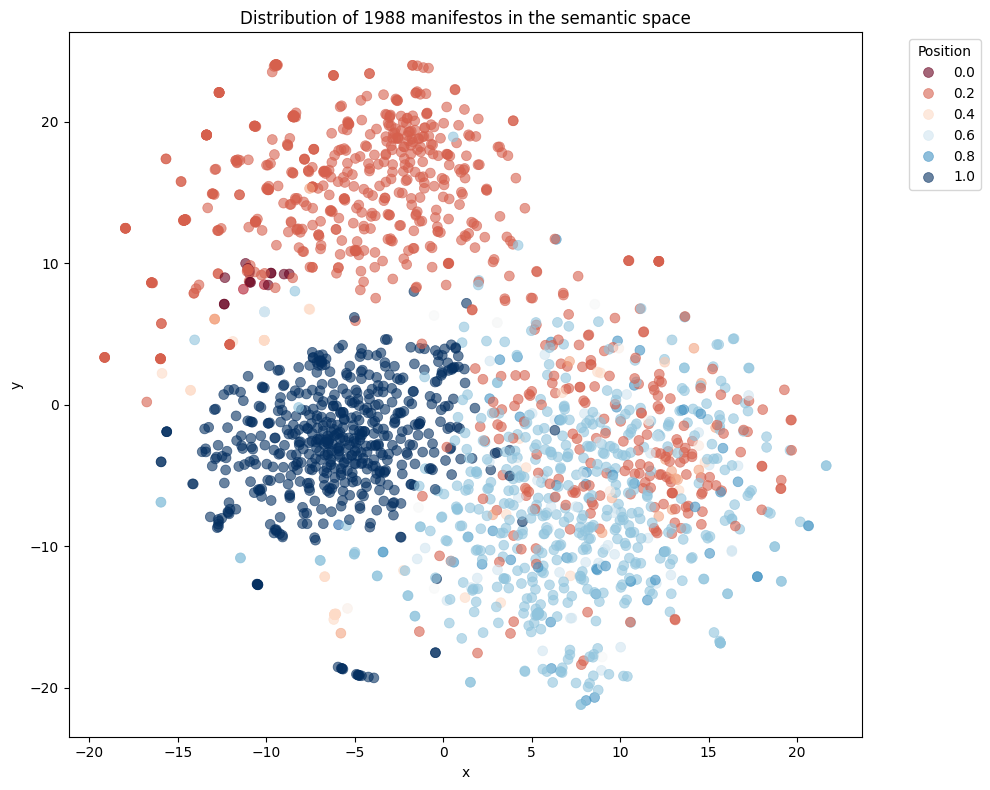

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
df_pandas = df.to_pandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pandas,
    x="x",
    y="y",
    hue="titulaire-soutien-position",
    palette="RdBu",  # Rouge (gauche) à Bleu (droite)
    alpha=0.6,
    s=50,
    edgecolor=None
)
plt.title("Distribution of 1988 manifestos in the semantic space")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Position")
plt.tight_layout()
plt.savefig("visualization.png")
plt.show()


<Figure size 640x480 with 0 Axes>